✅ Libraries imported successfully!
✅ Data loaded successfully from GitHub!
Shape: 1470 rows, 31 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  14

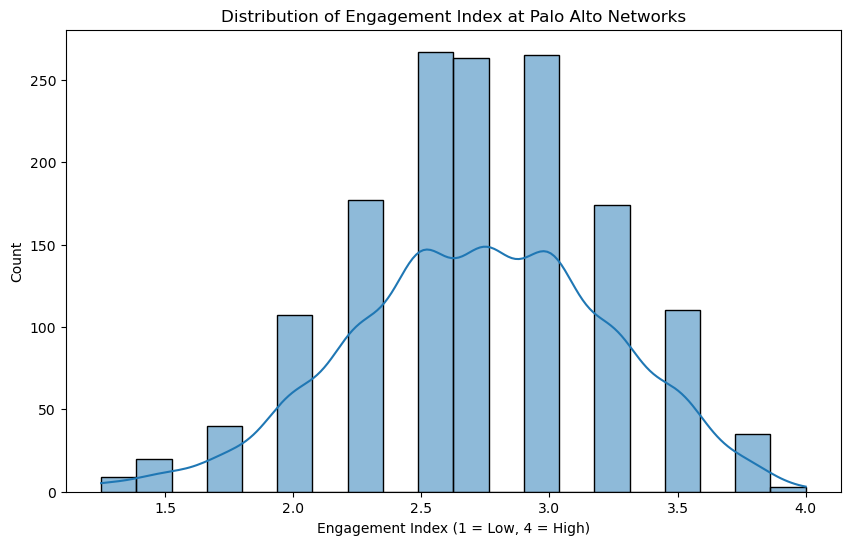

✅ Engagement Index created and saved!

=== STEP 3: Burnout Risk Identification ===
BurnoutRiskLevel
Low       756
Medium    588
High      126
Name: count, dtype: int64


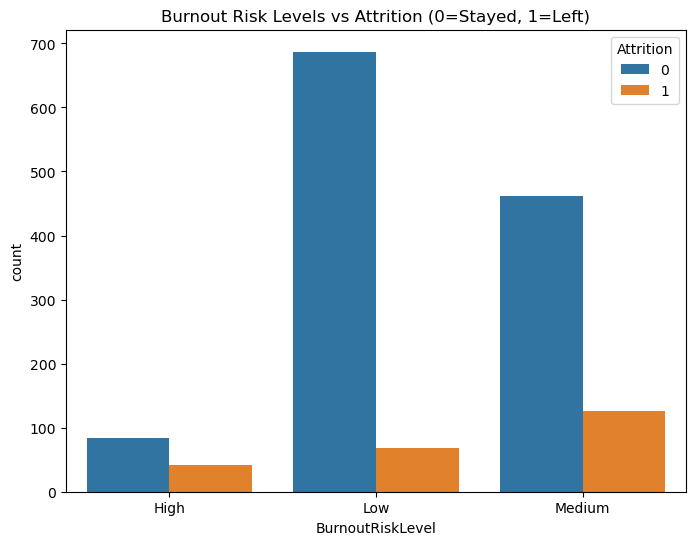

✅ Burnout Risk levels created and saved!

=== STEP 4: Workload & Stress Analysis ===


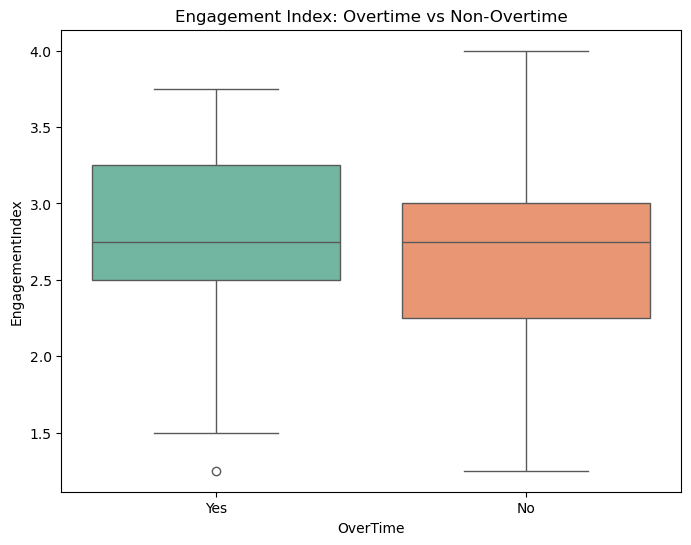

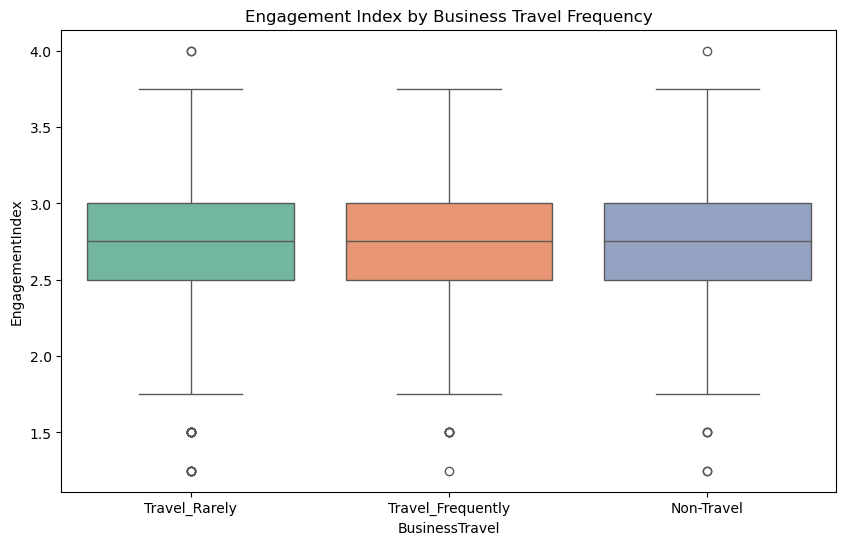

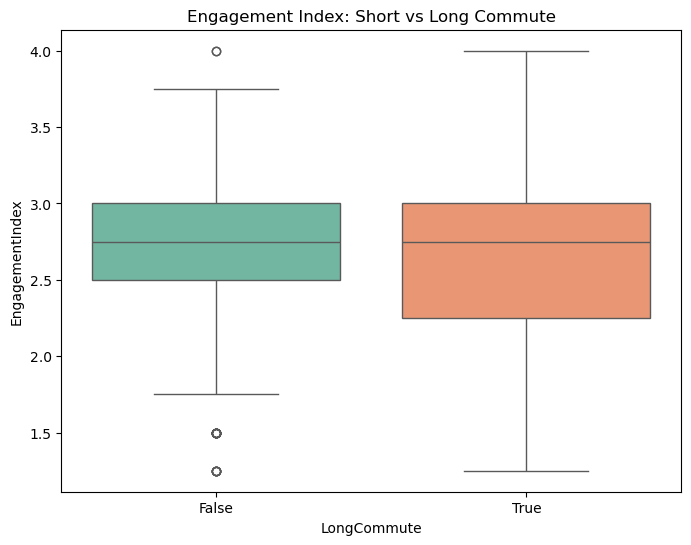

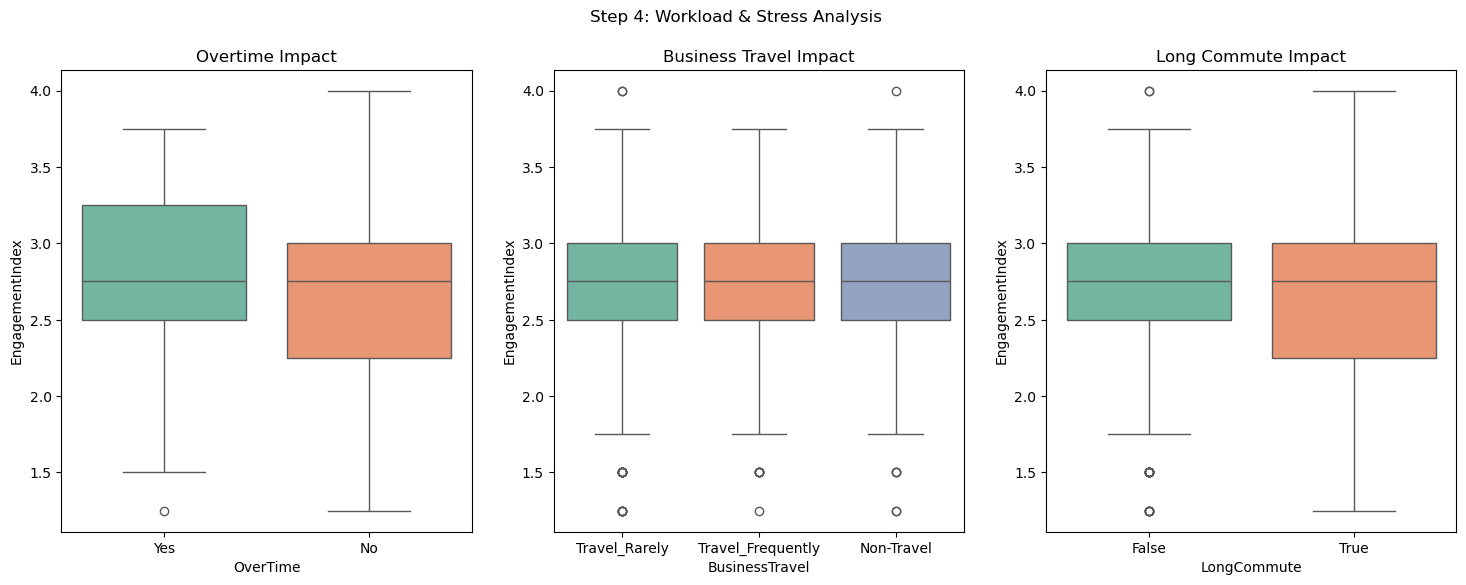

✅ Workload & Stress Analysis visuals saved!

=== STEP 5: Career-Stage Engagement Analysis ===
StagnationRisk
False    2.722363
True     2.726316
Name: EngagementIndex, dtype: float64


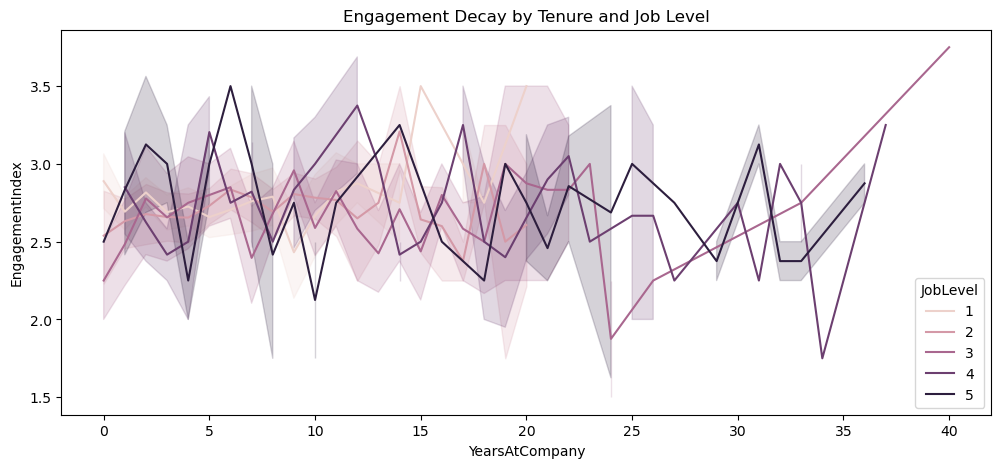

✅ Step 5: Only original line chart saved!

=== STEP 6: Engagement vs Attrition (Contextual Only) ===
Average Engagement Index:
Attrition
0    2.763585
1    2.512658
Name: EngagementIndex, dtype: float64
Mann-Whitney p-value: 0.0000

🎉 All 6 Analytical Steps Completed Successfully!
All visuals have been saved in the 'visuals' folder.


In [5]:
# ========================================================
# Employee Engagement, Satisfaction, and Burnout Diagnostic Analysis
# at Palo Alto Networks
# Preventive HR Analytics - Early Warning System
# ========================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
import os

# Create visuals folder
os.makedirs("visuals", exist_ok=True)

print("✅ Libraries imported successfully!")

# ====================== STEP 1: Data Loading from GitHub ======================
url = "https://raw.githubusercontent.com/Sunny777Solomon/Employee-Engagement-Satisfaction-and-Burnout-Diagnostic-Analysis-at-Palo-Alto-Networks/main/Palo%20Alto%20Networks.csv"

df = pd.read_csv(url)

print("✅ Data loaded successfully from GitHub!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

df
df.describe()
df.info()

# ====================== STEP 1: Data Validation & Normalization ======================
print("\n=== STEP 1: Data Validation & Normalization ===")

ordinal_cols = ['EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction',
                'RelationshipSatisfaction', 'WorkLifeBalance', 'PerformanceRating']

for col in ordinal_cols:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}, missing={df[col].isnull().sum()}")

# Handle missing values
df[ordinal_cols] = df[ordinal_cols].fillna(df[ordinal_cols].median())

# Normalize using Z-score
scaler = StandardScaler()
z_cols = ['EnvS_z', 'JobInv_z', 'JobSat_z', 'RelS_z']
df[z_cols] = scaler.fit_transform(df[['EnvironmentSatisfaction', 'JobInvolvement',
                                      'JobSatisfaction', 'RelationshipSatisfaction']])

print("✅ Data Validation & Normalization completed!")

# ====================== STEP 2: Engagement Index Construction ======================
print("\n=== STEP 2: Engagement Index Construction ===")

engagement_cols = ['JobInvolvement', 'JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction']

df['EngagementIndex'] = df[engagement_cols].mean(axis=1)
df['EngagementIndex_z'] = df[z_cols].mean(axis=1)

print(f"Overall Engagement Index Mean: {df['EngagementIndex'].mean():.3f}")

# Save visualization
plt.figure(figsize=(10,6))
sns.histplot(df['EngagementIndex'], kde=True, bins=20)
plt.title("Distribution of Engagement Index at Palo Alto Networks")
plt.xlabel("Engagement Index (1 = Low, 4 = High)")
plt.savefig("visuals/step2_engagement_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Engagement Index created and saved!")

# ====================== STEP 3: Burnout Risk Identification ======================
print("\n=== STEP 3: Burnout Risk Identification ===")

df['BurnoutHighRisk'] = ((df['OverTime'] == 'Yes') & (df['WorkLifeBalance'] <= 2)).astype(int)

conditions = [
    (df['OverTime'] == 'Yes') & (df['WorkLifeBalance'] <= 2),
    (df['OverTime'] == 'Yes') | (df['WorkLifeBalance'] <= 2)
]
df['BurnoutRiskLevel'] = pd.Series(np.select(conditions, ['High', 'Medium'], default='Low'))

print(df['BurnoutRiskLevel'].value_counts())

# Visualization
plt.figure(figsize=(8,6))
sns.countplot(x='BurnoutRiskLevel', hue='Attrition', data=df)
plt.title("Burnout Risk Levels vs Attrition (0=Stayed, 1=Left)")
plt.savefig("visuals/step3_burnout_risk_vs_attrition.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Burnout Risk levels created and saved!")

# ====================== STEP 4: Workload & Stress Analysis ======================
print("\n=== STEP 4: Workload & Stress Analysis ===")

df['LongCommute'] = df['DistanceFromHome'] > 10

# 1. Overtime Impact
plt.figure(figsize=(8,6))
sns.boxplot(x='OverTime', y='EngagementIndex', data=df, hue='OverTime', palette="Set2", legend=False)
plt.title("Engagement Index: Overtime vs Non-Overtime")
plt.savefig("visuals/step4_overtime_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

# 2. Business Travel Impact
plt.figure(figsize=(10,6))
sns.boxplot(x='BusinessTravel', y='EngagementIndex', data=df, hue='BusinessTravel', palette="Set2", legend=False)
plt.title("Engagement Index by Business Travel Frequency")
plt.savefig("visuals/step4_travel_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

# 3. Long Commute Impact
plt.figure(figsize=(8,6))
sns.boxplot(x='LongCommute', y='EngagementIndex', data=df, hue='LongCommute', palette="Set2", legend=False)
plt.title("Engagement Index: Short vs Long Commute")
plt.savefig("visuals/step4_commute_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

# Combined Visual for Step 4
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.boxplot(ax=axes[0], x='OverTime', y='EngagementIndex', data=df, hue='OverTime', palette="Set2", legend=False)
axes[0].set_title("Overtime Impact")
sns.boxplot(ax=axes[1], x='BusinessTravel', y='EngagementIndex', data=df, hue='BusinessTravel', palette="Set2", legend=False)
axes[1].set_title("Business Travel Impact")
sns.boxplot(ax=axes[2], x='LongCommute', y='EngagementIndex', data=df, hue='LongCommute', palette="Set2", legend=False)
axes[2].set_title("Long Commute Impact")
plt.suptitle("Step 4: Workload & Stress Analysis")
plt.savefig("visuals/step4_combined_workload_visuals.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Workload & Stress Analysis visuals saved!")

# ====================== STEP 5: Career-Stage Engagement Analysis ======================
print("\n=== STEP 5: Career-Stage Engagement Analysis ===")

# Line plot trends
plt.figure(figsize=(12,5))
sns.lineplot(x='YearsAtCompany', y='EngagementIndex', hue='JobLevel', data=df, errorbar=('ci', 95))
plt.title("Engagement Decay by Tenure and Job Level")
plt.savefig("career_stagnation.png", dpi=300)

# Stagnation flag (YearsInCurrentRole > 3 AND no promotion)
df['StagnationRisk'] = (df['YearsInCurrentRole'] > 3) & (df['YearsSinceLastPromotion'] > 3)
print(df.groupby('StagnationRisk')['EngagementIndex'].mean())
plt.show()

print("✅ Step 5: Only original line chart saved!")

# ====================== STEP 6: Engagement vs Attrition ======================
print("\n=== STEP 6: Engagement vs Attrition (Contextual Only) ===")

print("Average Engagement Index:")
print(df.groupby('Attrition')['EngagementIndex'].mean())

stat, p = stats.mannwhitneyu(df[df['Attrition']==1]['EngagementIndex'],
                             df[df['Attrition']==0]['EngagementIndex'])
print(f"Mann-Whitney p-value: {p:.4f}")

print("\n🎉 All 6 Analytical Steps Completed Successfully!")
print("All visuals have been saved in the 'visuals' folder.")